In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
%matplotlib inline

## Q1

In [22]:
# loading data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]

print(D.shape)
D[:5]

(100, 6)


array([[ -5.30547099,  -4.06009155,  -5.26129006, -12.66633342,
         -3.79615021,   3.69171161],
       [ -5.5403588 ,  -5.0031803 ,  -3.99259187, -11.00772693,
         -3.98562503,   4.90000402],
       [ -4.98212753,  -4.58449362,  -4.33122591, -11.69731474,
         -3.58927699,   5.04686274],
       [ -4.49570614,  -5.06413838,  -4.78201809, -11.97801037,
         -3.59707103,   4.63593624],
       [ -4.44215386,  -4.41137023,  -4.5675092 , -12.41495176,
         -2.79950409,   4.73969871]])

### (a) TLS on first line

In [23]:
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

In [24]:
def tls_fit(x, y):
    """fit line ax + by + c = 0 using total least squares"""
    xm = np.mean(x)
    ym = np.mean(y)
    
    # centre and do svd
    A = np.column_stack([x - xm, y - ym])
    U, S, Vt = np.linalg.svd(A)
    
    # normal direction is last row of Vt (smallest singular value)
    a, b = Vt[-1]
    c = -(a * xm + b * ym)
    return a, b, c

In [25]:
a, b, c = tls_fit(x1, y1)

print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print()

# converting to y = mx + d
m = -a/b
d = -c/b
print(f"y = {m:.4f}x + ({d:.4f})")

a = 0.773562
b = -0.633721
c = -3.794192

y = 1.2207x + (-5.9872)


#### Comparing TLS vs OLS on first line

In [26]:
# OLS fit for comparison
ols_coeffs = np.polyfit(x1, y1, 1)
m_ols, d_ols = ols_coeffs
print(f"OLS: y = {m_ols:.4f}x + ({d_ols:.4f})")
print(f"TLS: y = {m:.4f}x + ({d:.4f})")
print(f"\nslope diff: {abs(m - m_ols):.6f}")
print(f"intercept diff: {abs(d - d_ols):.6f}")

OLS: y = 1.1845x + (-5.9879)
TLS: y = 1.2207x + (-5.9872)

slope diff: 0.036192
intercept diff: 0.000706


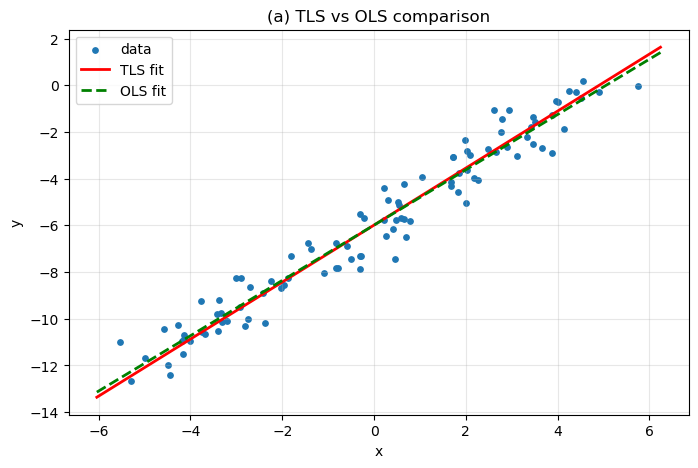

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(x1, y1, s=15, label='data')

xs = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 200)
ys_tls = (-a * xs - c) / b
ys_ols = m_ols * xs + d_ols
plt.plot(xs, ys_tls, 'r-', lw=2, label='TLS fit')
plt.plot(xs, ys_ols, 'g--', lw=2, label='OLS fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('(a) TLS vs OLS comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
# compare residuals
# TLS: orthogonal distance
tls_residuals = np.abs(a * x1 + b * y1 + c)
# OLS: vertical distance
ols_residuals = np.abs(y1 - (m_ols * x1 + d_ols))

print(f"TLS mean orthogonal residual: {np.mean(tls_residuals):.4f}")
print(f"OLS mean vertical residual:   {np.mean(ols_residuals):.4f}")
print(f"\nTLS gives smaller orthogonal errors since it minimises perpendicular distance")

TLS mean orthogonal residual: 0.4059
OLS mean vertical residual:   0.6422

TLS gives smaller orthogonal errors since it minimises perpendicular distance


### (b) RANSAC to fit 3 lines

In [29]:
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f"total points: {len(X_all)}")

total points: 300
